# Face crops with bbox buffer

This notebook detects faces in a photo and shows:

1. Full image with **tight** bboxes (solid) and **buffered** bboxes (dashed)
2. Per-face crop grid: tight vs buffered
3. Optional multi-buffer comparison for the first detected face

Buffer expands each side by `buffer_pct`% of bbox width/height (e.g. 10% adds 10% of width to left and right).

> **Setup:** `pip install -e .` and `mf download` from the repo root.

In [1]:
import sys
from pathlib import Path

NOTEBOOKS_DIR = Path.cwd()
if NOTEBOOKS_DIR.name == "notebooks":
    REPO_ROOT = NOTEBOOKS_DIR.parent
else:
    REPO_ROOT = NOTEBOOKS_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

from meta_face.imaging import load_image
from meta_face.tools.face_record import resolve_face_records

import _utils

## User input

Set `IMAGE_PATH` and `BUFFER_PCT` (percentage expansion per side).

In [2]:
IMAGE_PATH = Path("/tun/springSoccer2026/2026/05-May/20260502_101833.140.jpg")  # 7 faces
BUFFER_PCT = 15  # <-- adjust buffer percentage
FORCE_DETECT = False  # True to re-run SCRFD instead of loading face.scrfd.* from .scar

if not IMAGE_PATH.is_file():
    raise FileNotFoundError(f"Set IMAGE_PATH to an existing image: {IMAGE_PATH}")

In [3]:
image = load_image(IMAGE_PATH)
records, source = resolve_face_records(IMAGE_PATH, force=FORCE_DETECT, image=image)

verb = "Detected" if source == "detect" else "Loaded"
print(f"{verb} {len(records)} face(s) from {source}; buffer={BUFFER_PCT}% per side")

/projects/spring_photography/meta_face/venv_meta_face/lib/python3.11/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/jed/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/jed/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/jed/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/jed/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/jed/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (64

/projects/spring_photography/meta_face/venv_meta_face/lib/python3.11/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Detected 7 face(s); buffer=15% per side


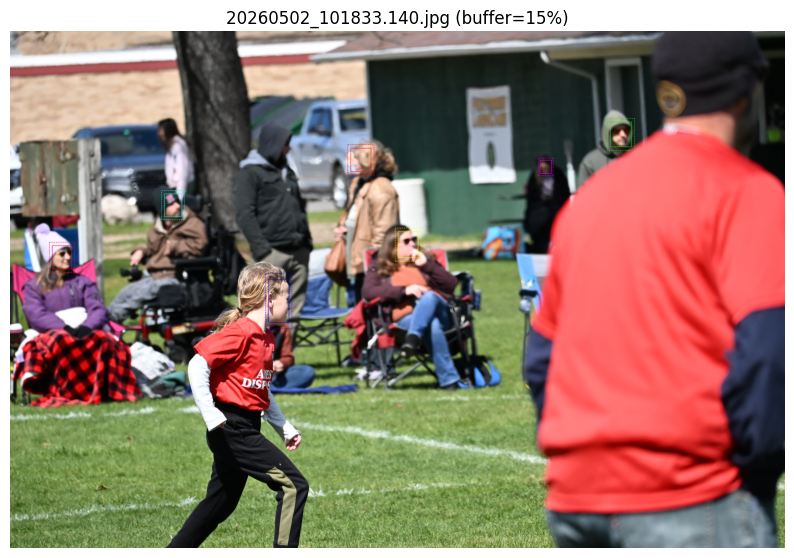

In [4]:
_utils.show_bbox_comparison(image, records, BUFFER_PCT, title=IMAGE_PATH.name)

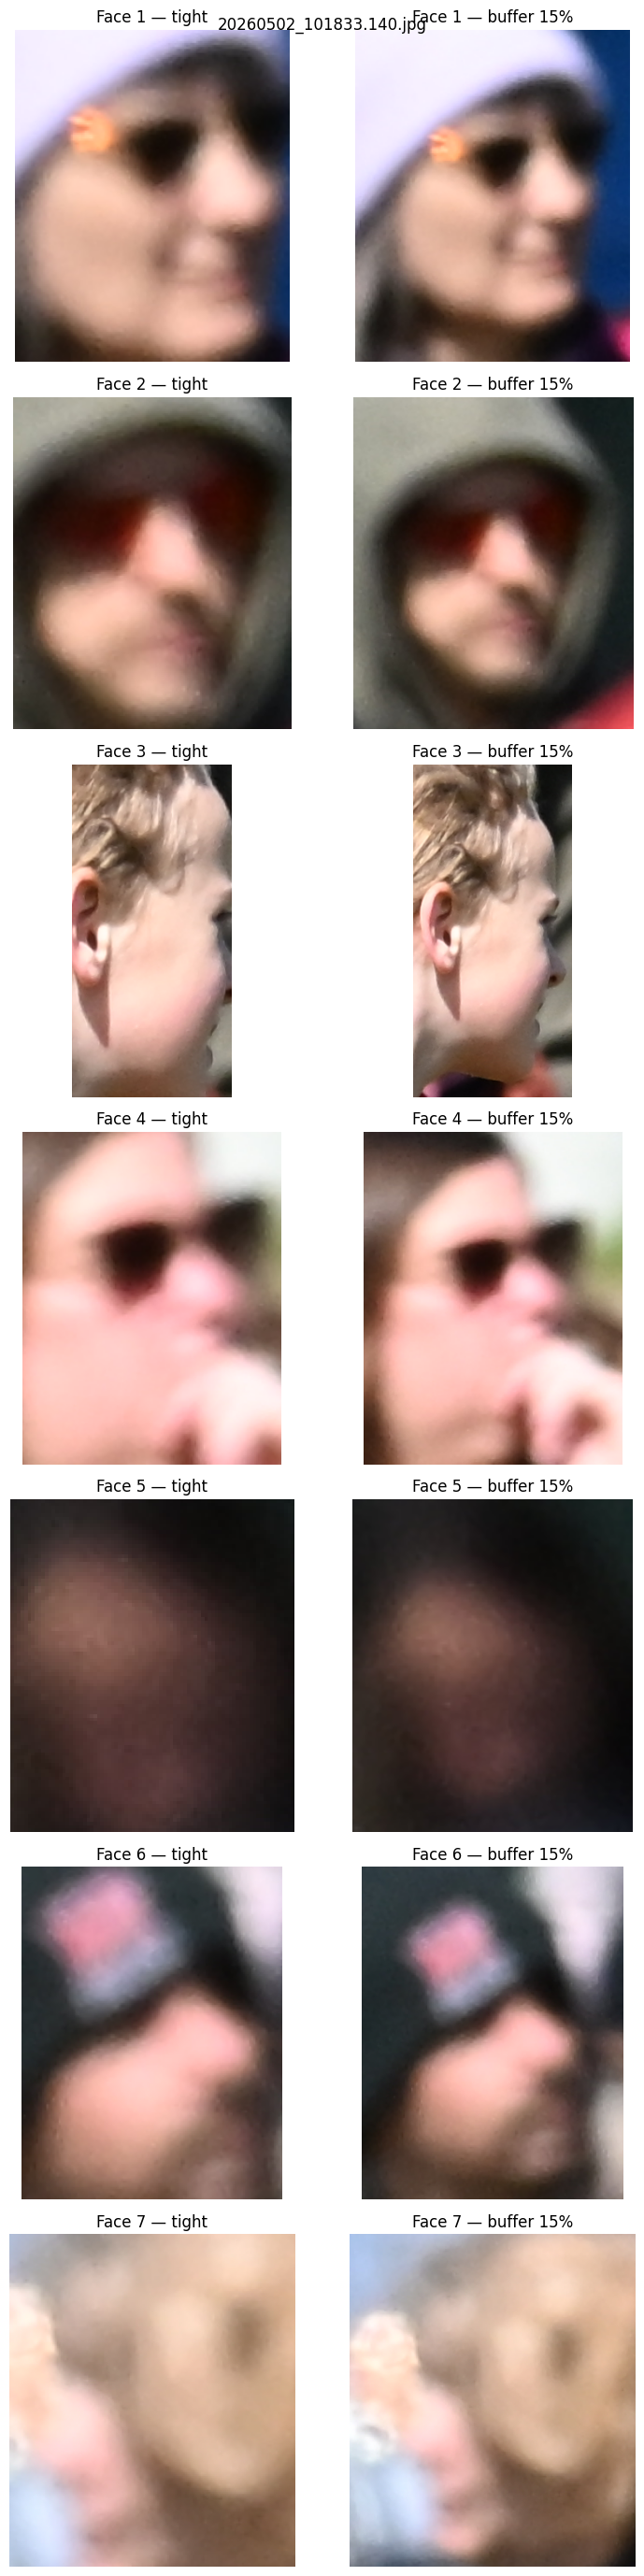

In [5]:
_utils.show_face_crop_grid(image, records, BUFFER_PCT, title=IMAGE_PATH.name)

## Multi-buffer comparison (first face)

Compare several buffer values for the first detected face.

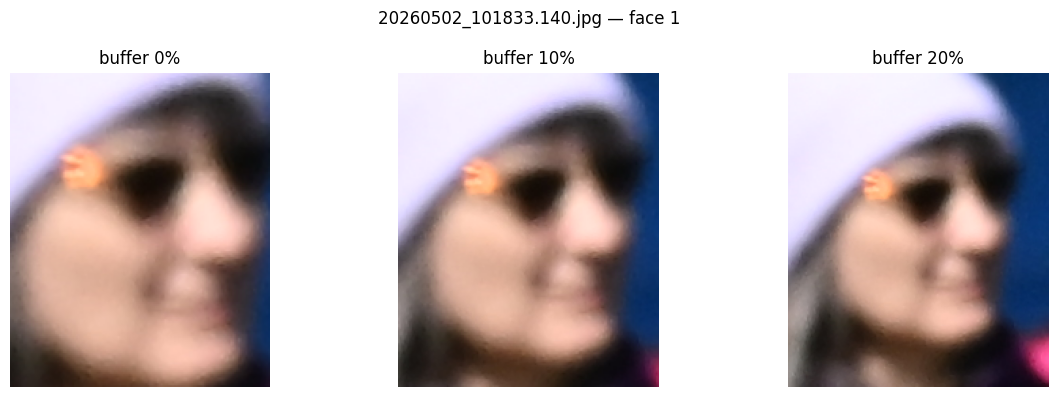

In [6]:
if records:
    _utils.show_buffer_comparison_row(
        image,
        records[0]["bbox"],
        [0, 10, 20],
        title=f"{IMAGE_PATH.name} — face 1",
    )
else:
    print("No faces detected.")